# 00 ? Quickstart

`QickworkspaceV2` is a self-contained automated quantum calibration framework built on QICK.
This notebook assumes a live QICK session.

What you will learn:
1. Start a QICK session
2. Build a hardware config
3. Run your first experiment
4. Inspect the `ExperimentData` result


In [1]:
import sys
sys.path.insert(0, r'../')   # adjust if running from a different directory

import QickworkspaceV2
print('QickworkspaceV2', QickworkspaceV2.__version__)

QickworkspaceV2 1.0.0


## 1. Start a QICK session

`BaseExperiment.connect_pyro4()` connects to the QICK board and registers `soc` / `soccfg` globally for experiment classes.


In [2]:
from QickworkspaceV2 import BaseExperiment

BaseExperiment.connect_pyro4(
    ns_host='192.168.10.82',
    data_path=r'D:\Labber_Data\Jay\test',
)


c:\Users\cluster\anaconda3\envs\qick_gui\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
QICK library version mismatch: 0.2.381 remote (the board), 0.2.405 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a0fa10b880d442359a82595a954ab5e1@192.168.10.82:44291
[BaseExperiment] Session activated: QICK@192.168.10.82:8888/myqick, data_path='D:\\Labber_Data\\Jay\\test'


(<Pyro4.core.Proxy at 0x1ddd29e63c0; connected IPv4; for PYRO:obj_a0fa10b880d442359a82595a954ab5e1@192.168.10.82:44291>,
 <qick.qick_asm.QickConfig at 0x1ddd28d7ec0>)

## 2. Load the current hardware config

Hardware keys and channel assignments are maintained in `QickworkspaceV2/config/system_cfg.py`.
Use that config as the source of truth, then add only the sweep values required by this run.


In [3]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2 import ExperimentConfig
from QickworkspaceV2.config.system_cfg import config_list

qubit = 'Q1'
cfg_all = ExperimentConfig(config_list)
base_cfg = cfg_all.get_qubit(qubit)
center = base_cfg['res_freq_ge']

cfg = cfg_all.get_qubit(qubit)
cfg.update([
    ('steps', 101),
    ('res_freq_ge', QickSweep1D('freqloop', center - 10, center + 10)),
    ('relax_delay', 0),
])
print('Configured qubits:', cfg_all.qubit_names())


Configured qubits: ['Q1', 'Q2', 'Q3', 'Q4']


## 3. Run Resonator Spectroscopy

`ResonatorSpec` sweeps the resonator drive frequency and fits a circle (ABCD hanger model)
to extract `f0`, `κ`, and `κ_c`.

In [4]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

expt = ResonatorSpec(cfg)
result = expt.run(py_avg=5)

c:\Users\cluster\Desktop\QickworksaceV2_proj-test2\tutorial\..\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


## 4. Inspect the result

`ExperimentData` is the unified return type from every experiment.  
It supports the old tuple-unpack style **and** a rich named dict.

In [5]:
from QickworkspaceV2 import QualityFlag

# New API
print('Experiment   :', result.experiment_type)
print('Quality      :', result.quality)
print('Fit result   :', result.fit_result)
print('Scalar result:', result.scalar_result)
print('x_axis shape :', result.x_axis.shape)
print('y_axis       :', result.y_axis.shape if result.y_axis is not None else 'None (1-D experiment)')

# Backward-compat tuple unpack
fit_params, fit_errors = result
print('fit_params   :', fit_params)

# Backward-compat scalar coercion
freq = float(result)
print(f'Resonator freq (scalar): {freq:.3f}')

Experiment   : s002_res_ge
Quality      : QualityFlag.BAD
Fit result   : {'f_res[MHz]': (np.float64(6708.6172), None), 'Qi': (3078, None), 'Qc': (0, None), 'Ql': (0, None), 'kappa_MHz': (np.float64(-0.9144), None)}
Scalar result: 6708.617204259656
x_axis shape : (101,)
y_axis       : None (1-D experiment)
fit_params   : None
Resonator freq (scalar): 6708.617


## 5. Quick plot

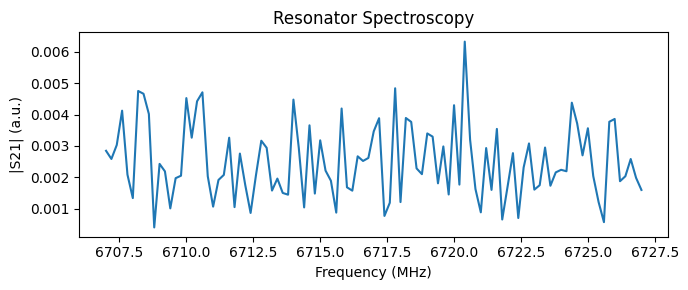

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 3))
plt.plot(result.x_axis, np.abs(result.raw_iq), lw=1.5)
plt.xlabel('Frequency (MHz)')
plt.ylabel('|S21| (a.u.)')
plt.title('Resonator Spectroscopy')
plt.tight_layout()


**Next:** [01_config_and_store.ipynb](01_config_and_store.ipynb) — managing experiment configuration and persisting calibration parameters.